Descàrrega de dades de Bitcoin i Or

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
btc = yf.download("BTC-USD", period="730d", interval="1h", auto_adjust=False)
gld = yf.download("GLD", period="730d", interval="1h", auto_adjust=False)

print("BTC shape:", btc.shape)
print("GLD shape:", gld.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC shape: (17351, 6)
GLD shape: (5077, 6)


Neteja de columnes multi índex

In [3]:
btc.columns = btc.columns.get_level_values(0)
gld.columns = gld.columns.get_level_values(0)

btc.head(), gld.head()

(Price                         Adj Close         Close          High  \
 Datetime                                                              
 2024-04-27 00:00:00+00:00  62937.859375  62937.859375  63894.988281   
 2024-04-27 01:00:00+00:00  62559.429688  62559.429688  63217.339844   
 2024-04-27 02:00:00+00:00  62934.085938  62934.085938  63265.148438   
 2024-04-27 03:00:00+00:00  63071.062500  63071.062500  63125.246094   
 2024-04-27 04:00:00+00:00  62996.097656  62996.097656  63115.500000   
 
 Price                               Low          Open     Volume  
 Datetime                                                          
 2024-04-27 00:00:00+00:00  62852.578125  63753.121094          0  
 2024-04-27 01:00:00+00:00  62517.667969  63134.039062  580343808  
 2024-04-27 02:00:00+00:00  62509.085938  62581.515625  270473216  
 2024-04-27 03:00:00+00:00  62858.570312  62927.632812          0  
 2024-04-27 04:00:00+00:00  62939.726562  63065.574219          0  ,
 Price           

Verificació ràpida

In [4]:
print(btc.columns)
print(gld.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Sincronització de dades de Bitcoin i Or.
Rang de dates coherent (Bitcoin funciona 24 hores, però l'or no).
Normalitzar timestamps a inici d'hora.
Renombrar columnes.

In [5]:
btc_1h = btc[["Close"]].copy()
gld_1h = gld[["Close"]].copy()

btc_1h.index = btc_1h.index.floor("1h")
gld_1h.index = gld_1h.index.floor("1h")

btc_1h.columns.name = None
gld_1h.columns.name = None

btc_1h = btc_1h.rename(columns={"Close": "btc_close"})
gld_1h = gld_1h.rename(columns={"Close": "gld_close"})

print(btc_1h.head())
print(gld_1h.head())

                              btc_close
Datetime                               
2024-04-27 00:00:00+00:00  62937.859375
2024-04-27 01:00:00+00:00  62559.429688
2024-04-27 02:00:00+00:00  62934.085938
2024-04-27 03:00:00+00:00  63071.062500
2024-04-27 04:00:00+00:00  62996.097656
                            gld_close
Datetime                             
2023-05-26 13:00:00+00:00  180.960007
2023-05-26 14:00:00+00:00  180.419998
2023-05-26 15:00:00+00:00  180.740005
2023-05-26 16:00:00+00:00  180.600006
2023-05-26 17:00:00+00:00  180.789993


Obtenir intersecció de dades

In [6]:
common_index = btc_1h.index.intersection(gld_1h.index)

btc_sync = btc_1h.loc[common_index].copy()
gld_sync = gld_1h.loc[common_index].copy()

print("BTC sync shape:", btc_sync.shape)
print("GLD sync shape:", gld_sync.shape)
print("Start:", common_index.min())
print("End:", common_index.max())

BTC sync shape: (3440, 1)
GLD sync shape: (3440, 1)
Start: 2024-04-29 13:00:00+00:00
End: 2026-04-24 19:00:00+00:00


Fusió de datasets de Bitcoin i Or

In [7]:
df = btc_sync.join(gld_sync, how="inner")

print("Merged shape:", df.shape)
df.head()

Merged shape: (3440, 2)


,btc_close,gld_close
Datetime,,
2024-04-29 13:00:00+00:00,61974.937500,216.470001
2024-04-29 14:00:00+00:00,62847.734375,216.360001
2024-04-29 15:00:00+00:00,62991.269531,216.929993
2024-04-29 16:00:00+00:00,62789.363281,217.130005
2024-04-29 17:00:00+00:00,63042.710938,216.440002


Crear returns

In [8]:
df["btc_ret_1h"] = df["btc_close"].pct_change()
df["gld_ret_1h"] = df["gld_close"].pct_change()

df = df.dropna().copy()

df.head()

,btc_close,gld_close,btc_ret_1h,gld_ret_1h
Datetime,,,,
2024-04-29 14:00:00+00:00,62847.734375,216.360001,0.014083,-0.000508
2024-04-29 15:00:00+00:00,62991.269531,216.929993,0.002284,0.002634
2024-04-29 16:00:00+00:00,62789.363281,217.130005,-0.003205,0.000922
2024-04-29 17:00:00+00:00,63042.710938,216.440002,0.004035,-0.003178
2024-04-29 18:00:00+00:00,62845.902344,216.179993,-0.003122,-0.001201


Passar a 4 hores, resamplejant el dataset. Frame final.

In [9]:
df_4h = df.resample("4h").agg({
    "btc_close": "last",
    "gld_close": "last",
    "btc_ret_1h": "sum",
    "gld_ret_1h": "sum"
}).dropna().copy()

print("4H shape:", df_4h.shape)
df_4h.head()

4H shape: (1149, 4)


,btc_close,gld_close,btc_ret_1h,gld_ret_1h
Datetime,,,,
2024-04-29 12:00:00+00:00,62991.269531,216.929993,0.016367,0.002126
2024-04-29 16:00:00+00:00,62862.511719,216.169998,-0.002028,-0.003503
2024-04-30 12:00:00+00:00,60787.402344,212.737396,-0.032995,-0.015897
2024-04-30 16:00:00+00:00,59120.066406,211.970001,-0.027629,-0.003608
2024-05-01 12:00:00+00:00,56792.820312,213.410004,-0.039570,0.006795


Creació de features mínimes útils

In [10]:
df_4h["btc_ret_4h"] = df_4h["btc_close"].pct_change()
df_4h["gld_ret_4h"] = df_4h["gld_close"].pct_change()

df_4h["btc_vol_12"] = df_4h["btc_ret_4h"].rolling(12).std()
df_4h["gld_vol_12"] = df_4h["gld_ret_4h"].rolling(12).std()

df_4h = df_4h.dropna().copy()

print("Final 4H shape:", df_4h.shape)
df_4h.head()

Final 4H shape: (1137, 8)


,btc_close,gld_close,btc_ret_1h,gld_ret_1h,btc_ret_4h,gld_ret_4h,btc_vol_12,gld_vol_12
Datetime,,,,,,,,
2024-05-07 12:00:00+00:00,63724.531250,214.300003,0.008454,-0.004047,0.008434,-0.004043,0.026712,0.006463
2024-05-07 16:00:00+00:00,62989.285156,214.214996,-0.011587,-0.000396,-0.011538,-0.000397,0.026959,0.006415
2024-05-08 12:00:00+00:00,62276.804688,214.600006,-0.011303,0.001796,-0.011311,0.001797,0.025176,0.004305
2024-05-08 16:00:00+00:00,62233.468750,213.589996,-0.000680,-0.004714,-0.000696,-0.004706,0.023427,0.004416
2024-05-09 12:00:00+00:00,62121.359375,215.968994,-0.001573,0.011144,-0.001801,0.011138,0.019146,0.005092


In [11]:
features = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]

df_model = df_4h[features].copy()

print(df_model.shape)
df_model.head()

(1137, 4)


,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,
2024-05-07 12:00:00+00:00,0.008434,0.026712,-0.004043,0.006463
2024-05-07 16:00:00+00:00,-0.011538,0.026959,-0.000397,0.006415
2024-05-08 12:00:00+00:00,-0.011311,0.025176,0.001797,0.004305
2024-05-08 16:00:00+00:00,-0.000696,0.023427,-0.004706,0.004416
2024-05-09 12:00:00+00:00,-0.001801,0.019146,0.011138,0.005092


In [12]:
env_df = df_4h[[
    "btc_close",
    "btc_ret_4h",
    "btc_vol_12",
    "gld_ret_4h",
    "gld_vol_12"
]].copy()

print(env_df.shape)
env_df.head()

(1137, 5)


,btc_close,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,,
2024-05-07 12:00:00+00:00,63724.531250,0.008434,0.026712,-0.004043,0.006463
2024-05-07 16:00:00+00:00,62989.285156,-0.011538,0.026959,-0.000397,0.006415
2024-05-08 12:00:00+00:00,62276.804688,-0.011311,0.025176,0.001797,0.004305
2024-05-08 16:00:00+00:00,62233.468750,-0.000696,0.023427,-0.004706,0.004416
2024-05-09 12:00:00+00:00,62121.359375,-0.001801,0.019146,0.011138,0.005092


Baseline només BTC

In [13]:
btc_features = ["btc_ret_4h", "btc_vol_12"]
env_btc = env_df[["btc_close"] + btc_features].copy()

print(env_btc.shape)
env_btc.head()

(1137, 3)


,btc_close,btc_ret_4h,btc_vol_12
Datetime,,,
2024-05-07 12:00:00+00:00,63724.531250,0.008434,0.026712
2024-05-07 16:00:00+00:00,62989.285156,-0.011538,0.026959
2024-05-08 12:00:00+00:00,62276.804688,-0.011311,0.025176
2024-05-08 16:00:00+00:00,62233.468750,-0.000696,0.023427
2024-05-09 12:00:00+00:00,62121.359375,-0.001801,0.019146


Model amb senyal exògena (BTC + GLD)

In [14]:
btc_gld_features = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]
env_btc_gld = env_df[["btc_close"] + btc_gld_features].copy()

print(env_btc_gld.shape)
env_btc_gld.head()

(1137, 5)


,btc_close,btc_ret_4h,btc_vol_12,gld_ret_4h,gld_vol_12
Datetime,,,,,
2024-05-07 12:00:00+00:00,63724.531250,0.008434,0.026712,-0.004043,0.006463
2024-05-07 16:00:00+00:00,62989.285156,-0.011538,0.026959,-0.000397,0.006415
2024-05-08 12:00:00+00:00,62276.804688,-0.011311,0.025176,0.001797,0.004305
2024-05-08 16:00:00+00:00,62233.468750,-0.000696,0.023427,-0.004706,0.004416
2024-05-09 12:00:00+00:00,62121.359375,-0.001801,0.019146,0.011138,0.005092


Split de Train / Test

In [15]:
split_idx = int(len(env_df) * 0.8)

train_btc = env_btc.iloc[:split_idx].copy()
test_btc  = env_btc.iloc[split_idx:].copy()

train_btc_gld = env_btc_gld.iloc[:split_idx].copy()
test_btc_gld  = env_btc_gld.iloc[split_idx:].copy()

print("train_btc:", train_btc.shape)
print("test_btc:", test_btc.shape)
print("train_btc_gld:", train_btc_gld.shape)
print("test_btc_gld:", test_btc_gld.shape)

train_btc: (909, 3)
test_btc: (228, 3)
train_btc_gld: (909, 5)
test_btc_gld: (228, 5)


Importació de l'entorn Gym

In [16]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from env.trading_env_holding_penalty import TradingEnv

Crear entorn baseline

In [17]:
EXPERIMENT_NAME = "holding_penalty"
REWARD_TYPE = "holding_penalty"
TRANSACTION_COST = 0.0
TOTAL_TIMESTEPS = 50000
ALPHA = 0.05
BETA = 0.001

print("Experiment:", EXPERIMENT_NAME)
print("Reward:", REWARD_TYPE)
print("Transaction cost:", TRANSACTION_COST)
print("Timesteps:", TOTAL_TIMESTEPS)
print("Alpha:", ALPHA)

Experiment: holding_penalty
Reward: holding_penalty
Transaction cost: 0.0
Timesteps: 50000
Alpha: 0.05


In [18]:
btc_feature_columns = ["btc_ret_4h", "btc_vol_12"]

env_train_btc_holding = TradingEnv(
    data=train_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

obs, info = env_train_btc_holding.reset()
print("Initial observation:", obs)
print("Observation shape:", obs.shape)
print("Info:", info)

Initial observation: [0.00843361 0.02671173 0.         0.        ]
Observation shape: (4,)
Info: {}


Test d'uns steps

In [19]:
obs, reward, done, truncated, info = env_train_btc_holding.step(1)  # long
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

obs, reward, done, truncated, info = env_train_btc_holding.step(0)  # hold
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Reward: -0.013873467916979791
Done: False
Info: {'step': 1, 'position': 1, 'asset_return': np.float64(-0.01153788155562152), 'volatility': np.float64(0.026711727227165385), 'holding_duration': 1}
Reward: -0.014659084420270446
Done: False
Info: {'step': 2, 'position': 1, 'asset_return': np.float64(-0.011311137552722395), 'volatility': np.float64(0.026958937350961023), 'holding_duration': 2}


Test de l'entorn amb GLD

In [20]:
btc_gld_feature_columns = ["btc_ret_4h", "btc_vol_12", "gld_ret_4h", "gld_vol_12"]

env_train_btc_gld_holding = TradingEnv(
    data=train_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

obs, info = env_train_btc_gld_holding.reset()
print("BTC+GLD train initial observation:", obs)
print("BTC+GLD train observation shape:", obs.shape)
print("Info:", info)

BTC+GLD train initial observation: [ 0.00843361  0.02671173 -0.00404329  0.00646271  0.          0.        ]
BTC+GLD train observation shape: (6,)
Info: {}


In [21]:
obs, reward, done, truncated, info = env_train_btc_gld_holding.step(1)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Reward: -0.013873467916979791
Done: False
Info: {'step': 1, 'position': 1, 'asset_return': np.float64(-0.01153788155562152), 'volatility': np.float64(0.026711727227165385), 'holding_duration': 1}


Crear entorns de test

In [22]:
env_test_btc_holding = TradingEnv(
    data=test_btc,
    feature_columns=btc_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

obs, info = env_test_btc_holding.reset()
print("BTC test initial observation:", obs)
print("BTC test observation shape:", obs.shape)
print("Info:", info)

env_test_btc_gld_holding = TradingEnv(
    data=test_btc_gld,
    feature_columns=btc_gld_feature_columns,
    price_column="btc_close",
    transaction_cost=TRANSACTION_COST,
    volatility_column="btc_vol_12",
    alpha=ALPHA,
    beta=BETA,
)

obs, info = env_test_btc_gld_holding.reset()
print("BTC+GLD test initial observation:", obs)
print("BTC+GLD test observation shape:", obs.shape)
print("Info:", info)

BTC test initial observation: [-0.01518032  0.01521245  0.          0.        ]
BTC test observation shape: (4,)
Info: {}
BTC+GLD test initial observation: [-0.01518032  0.01521245  0.00331718  0.00189636  0.          0.        ]
BTC+GLD test observation shape: (6,)
Info: {}


Entrenaments amb PPO

In [23]:
from stable_baselines3 import PPO

Model de BTC

In [24]:
model_btc_vol = PPO(
    "MlpPolicy",
    env_train_btc_holding,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_vol.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 916 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 721         |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.004715981 |
|    clip_fraction        | 0.0043      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | -4.11       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00801     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00346    |
|    value_loss           | 0.0

Model de BTC + GLD

In [25]:
model_btc_gld_vol = PPO(
    "MlpPolicy",
    env_train_btc_gld_holding,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
)

model_btc_gld_vol.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------
| time/              |     |
|    fps             | 766 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 627         |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 512         |
| train/                  |             |
|    approx_kl            | 0.009611775 |
|    clip_fraction        | 0.027       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | -5.39       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.00195    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00639    |
|    value_loss           | 0.0

Guardar models

In [26]:
model_btc_vol.save("../results/model_btc_baseline")
model_btc_gld_vol.save("../results/model_btc_gld")

Avaluació en Test.
Retorna Equity Cruve, Rewards, Posicions i Retorns d'Estratègia.

In [27]:
import numpy as np
import pandas as pd

def evaluate_model(model, env, data_df):
    obs, info = env.reset()

    done = False
    truncated = False

    equity = [1.0]
    rewards = []
    positions = []
    asset_returns = []
    actions = []

    while not (done or truncated):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(int(action))

        rewards.append(reward)
        actions.append(int(action))
        positions.append(info["position"])
        asset_returns.append(info["asset_return"])

        equity.append(equity[-1] * (1.0 + reward))

    results = pd.DataFrame({
        "reward": rewards,
        "position": positions,
        "asset_return": asset_returns,
        "action": actions,
    }, index=data_df.index[1:1+len(rewards)])

    results["equity"] = equity[1:]
    return results

Execució en els dos models

In [28]:
results_btc_vol = evaluate_model(model_btc_vol, env_test_btc_holding, test_btc)
results_btc_gld_vol = evaluate_model(model_btc_gld_vol, env_test_btc_gld_holding, test_btc_gld)

results_btc_vol.head(), results_btc_gld_vol.head()

(                             reward  position  asset_return  action    equity
 Datetime                                                                     
 2025-12-17 20:00:00+00:00 -0.003210         1     -0.001450       1  0.996790
 2025-12-18 12:00:00+00:00 -0.032592        -1      0.030868       2  0.964302
 2025-12-18 16:00:00+00:00 -0.046586         1     -0.044742       1  0.919379
 2025-12-18 20:00:00+00:00 -0.004682        -1      0.002636       2  0.915074
 2025-12-19 12:00:00+00:00  0.034619         1      0.036669       1  0.946753,
                              reward  position  asset_return  action    equity
 Datetime                                                                     
 2025-12-17 20:00:00+00:00 -0.000311        -1     -0.001450       2  0.999689
 2025-12-18 12:00:00+00:00  0.029143         1      0.030868       1  1.028823
 2025-12-18 16:00:00+00:00  0.042898        -1     -0.044742       2  1.072957
 2025-12-18 20:00:00+00:00  0.000589         1     

In [29]:
results_btc_vol["action"].value_counts()
results_btc_gld_vol["action"].value_counts()

action
2    114
1    113
Name: count, dtype: int64

Funció de mètriques bàsiques

In [30]:
def compute_metrics(results_df, periods_per_year=252*2):
    rets = results_df["reward"].dropna()

    cumulative_return = (1 + rets).prod() - 1

    mean_ret = rets.mean()
    vol = rets.std()

    sharpe = np.nan
    if vol > 0:
        sharpe = (mean_ret / vol) * np.sqrt(periods_per_year)

    downside = rets[rets < 0].std()
    sortino = np.nan
    if downside > 0:
        sortino = (mean_ret / downside) * np.sqrt(periods_per_year)

    equity = results_df["equity"]
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_drawdown = drawdown.min()

    position_changes = results_df["position"].diff().fillna(0)
    initial_trade = 1 if results_df["position"].iloc[0] != 0 else 0
    n_trades = int((position_changes != 0).sum() + initial_trade)

    return {
        "cumulative_return": cumulative_return,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "n_trades": int(n_trades),
    }

Aplicació de la funció de mètriques

In [31]:
metrics_btc = compute_metrics(results_btc_vol)
metrics_btc_gld = compute_metrics(results_btc_gld_vol)

metrics_btc, metrics_btc_gld

({'cumulative_return': np.float64(-0.4648072656256046),
  'sharpe': np.float64(-2.976448083255675),
  'sortino': np.float64(-3.9025540256884854),
  'max_drawdown': np.float64(-0.46308363911075856),
  'n_trades': 227},
 {'cumulative_return': np.float64(-0.2754666536579746),
  'sharpe': np.float64(-1.433274018884822),
  'sortino': np.float64(-1.9643530481087514),
  'max_drawdown': np.float64(-0.3719327887860363),
  'n_trades': 227})

Taula comparativa

In [32]:
comparison = pd.DataFrame([metrics_btc, metrics_btc_gld], index=["BTC", "BTC+GLD"])
comparison

,cumulative_return,sharpe,sortino,max_drawdown,n_trades
BTC,-0.464807,-2.976448,-3.902554,-0.463084,227
BTC+GLD,-0.275467,-1.433274,-1.964353,-0.371933,227


Gràfica d'Equity

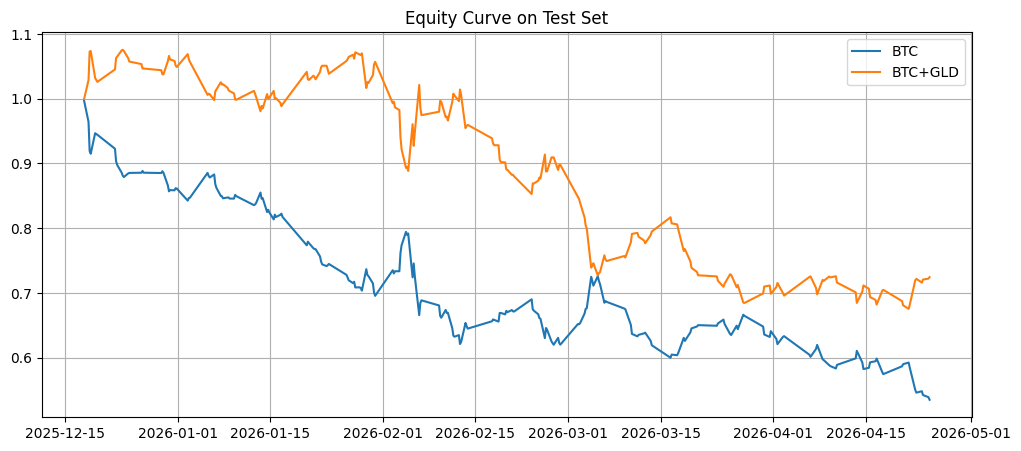

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(results_btc_vol.index, results_btc_vol["equity"], label="BTC")
plt.plot(results_btc_gld_vol.index, results_btc_gld_vol["equity"], label="BTC+GLD")
plt.title("Equity Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()

Comparació contra buy-and-hold

In [34]:
buy_hold_ret = test_btc["btc_close"].iloc[-1] / test_btc["btc_close"].iloc[0] - 1
print("Buy & Hold return:", buy_hold_ret)

Buy & Hold return: -0.09671170305064192


Veure accions dels dos models per separat

In [35]:
print("BTC actions:")
print(results_btc_vol["action"].value_counts())

print("\nBTC+GLD actions:")
print(results_btc_gld_vol["action"].value_counts())

print("\nBTC positions:")
print(results_btc_vol["position"].value_counts())

print("\nBTC+GLD positions:")
print(results_btc_gld_vol["position"].value_counts())

BTC actions:
action
1    114
2    113
Name: count, dtype: int64

BTC+GLD actions:
action
2    114
1    113
Name: count, dtype: int64

BTC positions:
position
 1    114
-1    113
Name: count, dtype: int64

BTC+GLD positions:
position
-1    114
 1    113
Name: count, dtype: int64
